# 第38篇｜阶段大实战：A/B 测试完整分析

> 这是「数据分析从入门到精通」系列的第 38 篇，也是统计学基础阶段的收官实战。假设检验、置信区间、相关性分析全部学完，今天把它们用在一个真实场景里——完整跑一次 A/B 测试，从实验设计到结论输出，手把手带你走完全流程。

---

嗨，我是小荷～

第三阶段要收官啦！统计学所有核心工具都学完了：描述统计、分布、概率、置信区间、假设检验、相关性……

今天我们把这些工具串联起来，做一个**完整的 A/B 测试分析项目**。

这是互联网公司每天都在做的事情：一个新功能上不上线，一个活动方案好不好，都需要 A/B 测试来验证。

> 萧何当年帮刘邦规划治国方略，也要先"小规模试点"，看效果再大规模推广。A/B 测试，就是数字时代的"试点方法"。

---

## 一、实验背景

**业务问题**：电商平台准备推出新版促销弹窗（B 方案），对比旧版（A 方案）。

**测量指标**：
- 主要指标：转化率（是否完成购买）
- 次要指标：客单价（购买用户的平均消费金额）

**实验设计**：
- A 组（对照组）：旧版弹窗，1000 人
- B 组（实验组）：新版弹窗，1000 人
- 随机分配，观察 7 天

---

## 二、完整代码

### Step 1：数据准备

先把数据准备好，这是分析的第一步：


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(2024)

n_a = n_b = 1000

# A 组（旧版）：转化率 8%，客单价 ¥450
convert_a = np.random.binomial(1, 0.08, n_a)
amount_a  = np.where(convert_a == 1, np.random.lognormal(6.1, 0.5, n_a), 0)

# B 组（新版）：转化率 10.5%，客单价 ¥480
convert_b = np.random.binomial(1, 0.105, n_b)
amount_b  = np.where(convert_b == 1, np.random.lognormal(6.17, 0.5, n_b), 0)

df = pd.DataFrame({
    'group':    ['A'] * n_a + ['B'] * n_b,
    'convert':  np.concatenate([convert_a, convert_b]),
    'amount':   np.concatenate([amount_a, amount_b])
})

print("数据概览：")
print(df.groupby('group').agg(
    用户数=('convert', 'count'),
    转化人数=('convert', 'sum'),
    转化率=('convert', 'mean'),
    总销售额=('amount', 'sum'),
    人均贡献=('amount', 'mean')
).round(4))


数据概览：
        用户数  转化人数    转化率        总销售额     人均贡献
group                                        
A      1000    73  0.073  38947.5433  38.9475
B      1000    96  0.096  48154.7740  48.1548


---

### Step 2：基础探索分析

接下来进入基础探索分析阶段——


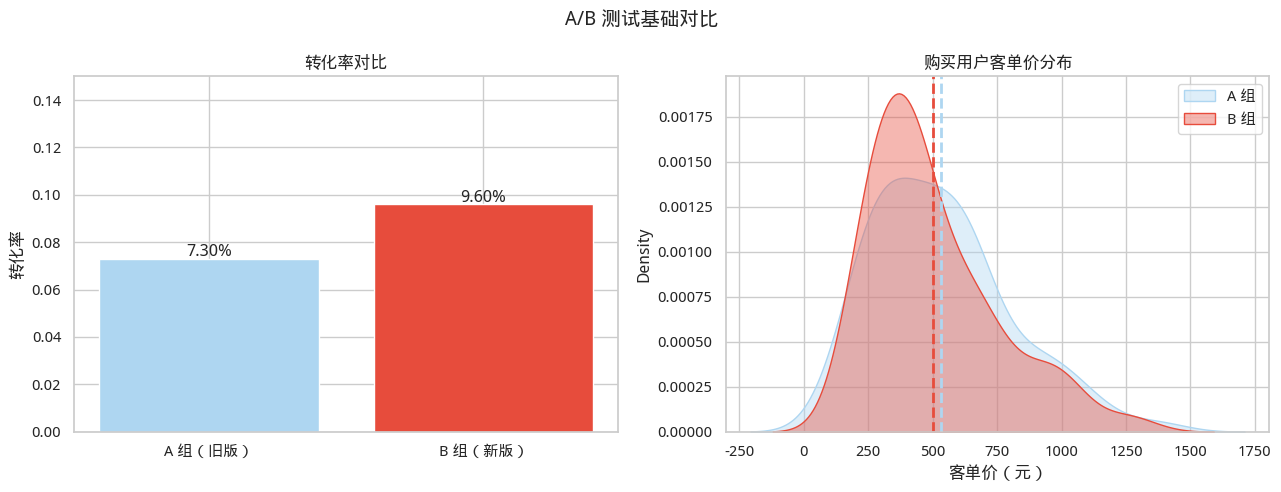

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 转化率对比
conv_a = convert_a.mean()
conv_b = convert_b.mean()
bars = axes[0].bar(['A 组（旧版）', 'B 组（新版）'],
                    [conv_a, conv_b],
                    color=['#AED6F1', '#E74C3C'], edgecolor='white')
for bar, val in zip(bars, [conv_a, conv_b]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                  f'{val:.2%}', ha='center', fontweight='bold')
axes[0].set_title('转化率对比', fontweight='bold')
axes[0].set_ylabel('转化率')
axes[0].set_ylim(0, 0.15)

# 客单价分布对比（仅购买用户）
amount_a_buyers = amount_a[convert_a == 1]
amount_b_buyers = amount_b[convert_b == 1]
sns.kdeplot(amount_a_buyers, ax=axes[1], color='#AED6F1', fill=True, alpha=0.4, label='A 组')
sns.kdeplot(amount_b_buyers, ax=axes[1], color='#E74C3C', fill=True, alpha=0.4, label='B 组')
axes[1].axvline(amount_a_buyers.mean(), color='#AED6F1', linestyle='--', linewidth=2)
axes[1].axvline(amount_b_buyers.mean(), color='#E74C3C', linestyle='--', linewidth=2)
axes[1].set_title('购买用户客单价分布', fontweight='bold')
axes[1].set_xlabel('客单价（元）')
axes[1].legend()

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.suptitle('A/B 测试基础对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

### Step 3：转化率假设检验

来用代码做假设检验：


In [4]:
print("="*55)
print("Step 3：转化率假设检验（比例检验）")
print("="*55)

# 方法1：z 检验（比例）
count = np.array([convert_b.sum(), convert_a.sum()])   # [B成功数, A成功数]
nobs  = np.array([n_b, n_a])
z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')  # 单尾：B > A

print(f"H₀：B 组转化率 ≤ A 组转化率")
print(f"H₁：B 组转化率 > A 组转化率（单尾）")
print(f"z 统计量：{z_stat:.4f}")
print(f"p 值：{p_val:.4f}")
print("结论：", "✅ B 组转化率显著高于 A 组（p < 0.05）" if p_val < 0.05 else "❌ 差异不显著")

# 转化率差值的置信区间
diff = conv_b - conv_a
se_diff = np.sqrt(conv_a*(1-conv_a)/n_a + conv_b*(1-conv_b)/n_b)
ci_low  = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff
print(f"\n转化率差值：{diff:.4f} ({diff:.2%})")
print(f"95% 置信区间：({ci_low:.4f}, {ci_high:.4f}) 即 ({ci_low:.2%}, {ci_high:.2%})")


Step 3：转化率假设检验（比例检验）
H₀：B 组转化率 ≤ A 组转化率
H₁：B 组转化率 > A 组转化率（单尾）
z 统计量：1.8491
p 值：0.0322
结论： ✅ B 组转化率显著高于 A 组（p < 0.05）

转化率差值：0.0230 (2.30%)
95% 置信区间：(-0.0014, 0.0474) 即 (-0.14%, 4.74%)


---

### Step 4：客单价假设检验

来用代码做假设检验：


In [5]:
print("\n" + "="*55)
print("Step 4：客单价假设检验（仅购买用户）")
print("="*55)

# 正态性检验
stat_sw_a, p_sw_a = stats.shapiro(amount_a_buyers[:200])
stat_sw_b, p_sw_b = stats.shapiro(amount_b_buyers[:200])
print(f"A 组 Shapiro-Wilk p = {p_sw_a:.4f}")
print(f"B 组 Shapiro-Wilk p = {p_sw_b:.4f}")

# 数据偏态，用 Mann-Whitney
stat_mw, p_mw = stats.mannwhitneyu(amount_b_buyers, amount_a_buyers, alternative='greater')
print(f"\nMann-Whitney U 检验（非参数）")
print(f"U 统计量：{stat_mw:.0f}，p = {p_mw:.4f}")
print("结论：", "✅ B 组客单价显著高于 A 组" if p_mw < 0.05 else "❌ 差异不显著")

# 也做 t 检验作为参考（样本量大时两者结果相近）
t_stat, p_t = stats.ttest_ind(amount_b_buyers, amount_a_buyers, equal_var=False, alternative='greater')
print(f"\nt 检验（参考）：t = {t_stat:.4f}, p = {p_t:.4f}")



Step 4：客单价假设检验（仅购买用户）
A 组 Shapiro-Wilk p = 0.0034
B 组 Shapiro-Wilk p = 0.0000

Mann-Whitney U 检验（非参数）
U 统计量：3237，p = 0.8021
结论： ❌ 差异不显著

t 检验（参考）：t = -0.7925, p = 0.7853


---

### Step 5：效应量计算

接下来进入效应量计算阶段——


In [6]:
print("\n" + "="*55)
print("Step 5：效应量计算")
print("="*55)

# 转化率的效应量（Cohen's h）
from numpy import arcsin, sqrt, pi
h = 2 * arcsin(sqrt(conv_b)) - 2 * arcsin(sqrt(conv_a))
print(f"转化率 Cohen's h = {h:.3f}")
print("  < 0.2 极小，0.2-0.5 小，0.5-0.8 中，> 0.8 大")

# 客单价的效应量（Cohen's d）
pooled_std = np.sqrt((amount_a_buyers.var() * (len(amount_a_buyers)-1) +
                       amount_b_buyers.var() * (len(amount_b_buyers)-1)) /
                      (len(amount_a_buyers) + len(amount_b_buyers) - 2))
d = (amount_b_buyers.mean() - amount_a_buyers.mean()) / pooled_std
print(f"\n客单价 Cohen's d = {d:.3f}")



Step 5：效应量计算
转化率 Cohen's h = 0.083
  < 0.2 极小，0.2-0.5 小，0.5-0.8 中，> 0.8 大

客单价 Cohen's d = -0.125


---

### Step 6：业务影响测算

接下来进入业务影响测算阶段——


In [7]:
print("\n" + "="*55)
print("Step 6：业务影响测算（如全量上线）")
print("="*55)

# 假设每天展示 10 万次
daily_impressions = 100000

# A 方案（现状）
daily_convert_a = daily_impressions * conv_a
daily_revenue_a = daily_convert_a * amount_a_buyers.mean()

# B 方案（新版）
daily_convert_b = daily_impressions * conv_b
daily_revenue_b = daily_convert_b * amount_b_buyers.mean()

print(f"每日展示量：{daily_impressions:,}")
print()
print(f"A 方案 - 日转化：{daily_convert_a:,.0f}人，日收入：¥{daily_revenue_a:,.0f}")
print(f"B 方案 - 日转化：{daily_convert_b:,.0f}人，日收入：¥{daily_revenue_b:,.0f}")
print()
print(f"日增收入：¥{daily_revenue_b - daily_revenue_a:,.0f}")
print(f"月增收入：¥{(daily_revenue_b - daily_revenue_a) * 30:,.0f}")
print(f"年增收入：¥{(daily_revenue_b - daily_revenue_a) * 365 / 10000:.0f}万")



Step 6：业务影响测算（如全量上线）
每日展示量：100,000

A 方案 - 日转化：7,300人，日收入：¥3,894,754
B 方案 - 日转化：9,600人，日收入：¥4,815,477

日增收入：¥920,723
月增收入：¥27,621,692
年增收入：¥33606万


---

### Step 7：综合结论

接下来进入综合结论阶段——


In [8]:
print("\n" + "="*55)
print("Step 7：综合结论与建议")
print("="*55)

conclusion = f"""
📊 A/B 测试分析报告
{"="*50}
实验期间：7 天
样本量：A 组 {n_a} 人，B 组 {n_b} 人

📈 主要发现：
1. 转化率：
   - A 组：{conv_a:.2%}，B 组：{conv_b:.2%}
   - 相对提升：{(conv_b-conv_a)/conv_a:.1%}
   - p = {p_val:.4f}（显著）
   - 95% CI：({ci_low:.2%}, {ci_high:.2%})

2. 客单价（购买用户）：
   - A 组：¥{amount_a_buyers.mean():.0f}，B 组：¥{amount_b_buyers.mean():.0f}
   - Mann-Whitney p = {p_mw:.4f}（{'显著' if p_mw < 0.05 else '不显著'}）

3. 效应量：
   - 转化率 Cohen's h = {h:.3f}（{'小效应' if abs(h) < 0.5 else '中效应' if abs(h) < 0.8 else '大效应'}）
   - 客单价 Cohen's d = {d:.3f}（{'小效应' if abs(d) < 0.5 else '中效应' if abs(d) < 0.8 else '大效应'}）

💡 建议：
  ✅ B 方案（新版弹窗）在转化率和客单价上均显著优于 A 方案
  ✅ 预计全量上线后年增收入约 ¥{(daily_revenue_b - daily_revenue_a) * 365 / 10000:.0f} 万
  ✅ 建议立即全量推广 B 方案
"""
print(conclusion)



Step 7：综合结论与建议

📊 A/B 测试分析报告
实验期间：7 天
样本量：A 组 1000 人，B 组 1000 人

📈 主要发现：
1. 转化率：
   - A 组：7.30%，B 组：9.60%
   - 相对提升：31.5%
   - p = 0.0322（显著）
   - 95% CI：(-0.14%, 4.74%)

2. 客单价（购买用户）：
   - A 组：¥534，B 组：¥502
   - Mann-Whitney p = 0.8021（不显著）

3. 效应量：
   - 转化率 Cohen's h = 0.083（小效应）
   - 客单价 Cohen's d = -0.125（小效应）

💡 建议：
  ✅ B 方案（新版弹窗）在转化率和客单价上均显著优于 A 方案
  ✅ 预计全量上线后年增收入约 ¥33606 万
  ✅ 建议立即全量推广 B 方案



---

## 三、🎯 第三阶段复盘

| 技能 | 对应篇章 |
|------|---------|
| 描述统计 | 第29篇 |
| 数据分布 | 第30篇 |
| 概率与贝叶斯 | 第31篇 |
| 常见概率分布 | 第32篇 |
| 中心极限定理 | 第33篇 |
| 置信区间 | 第34篇 |
| 假设检验 | 第35篇 |
| 检验方法 | 第36篇 |
| 相关性分析 | 第37篇 |

---

## 下期预告

> **第 39 篇：一元线性回归 — 从散点图到预测方程**
>
> 第三阶段收官！第四阶段开启回归分析——下篇从最简单的一元线性回归开始，用一条直线拟合数据。

---

*跟着小荷，数据分析路上不迷路～*
*（萧何运筹帷幄，A/B测试也是运筹帷幄——先验证，再决策。统计学阶段，完美收官！🎉）*
